# **Importing** **libraries**

In [43]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
nltk.download('stopwords')
nltk.download('punkt')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Loading** **Data**

In [44]:
df = pd.read_csv('/home/IMDB-Dataset.csv', on_bad_lines='skip', engine='python')
df.columns = ['text', 'label']
df.head(10)

,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


# **Cleaning** **Data**

In [45]:
def clean_text_regex(text):
    text = str(text).lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+|#', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\b\w{1,2}\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text_regex)
df = df[df['cleaned_text'].str.strip() != '']
df.head(10)

,text,label,cleaned_text
0,One of the other reviewers has mentioned that ...,positive,one the other reviewers has mentioned that aft...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...
2,I thought this was a wonderful way to spend ti...,positive,thought this was wonderful way spend time too ...
3,Basically there's a family where a little boy ...,negative,basically there family where little boy jake t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love the time money visually stu...
5,"Probably my all-time favorite movie, a story o...",positive,probably all time favorite movie story selfles...
6,I sure would like to see a resurrection of a u...,positive,sure would like see resurrection dated seahunt...
7,"This show was an amazing, fresh & innovative i...",negative,this show was amazing fresh innovative idea th...
8,Encouraged by the positive comments about this...,negative,encouraged the positive comments about this fi...
9,If you like original gut wrenching laughter yo...,positive,you like original gut wrenching laughter you w...


# **Text Preprocessing**

In [46]:
#Tokenization
if 'cleaned_text' not in df.columns:
    df['cleaned_text'] = df['text'].str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

df['tokenized'] = df['cleaned_text'].apply(lambda x: str(x).split())

from IPython.display import display
display(df[['cleaned_text', 'tokenized']].head())

,cleaned_text,tokenized
0,one the other reviewers has mentioned that aft...,"[one, the, other, reviewers, has, mentioned, t..."
1,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,thought this was wonderful way spend time too ...,"[thought, this, was, wonderful, way, spend, ti..."
3,basically there family where little boy jake t...,"[basically, there, family, where, little, boy,..."
4,petter mattei love the time money visually stu...,"[petter, mattei, love, the, time, money, visua..."


In [47]:
#Stop Words Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

df['no_stopwords'] = df['tokenized'].apply(remove_stopwords)
df[['tokenized', 'no_stopwords']].head()

,tokenized,no_stopwords
0,"[one, the, other, reviewers, has, mentioned, t...","[one, reviewers, mentioned, watching, episode,..."
1,"[wonderful, little, production, the, filming, ...","[wonderful, little, production, filming, techn..."
2,"[thought, this, was, wonderful, way, spend, ti...","[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, there, family, where, little, boy,...","[basically, family, little, boy, jake, thinks,..."
4,"[petter, mattei, love, the, time, money, visua...","[petter, mattei, love, time, money, visually, ..."


In [48]:
#Lemmetization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(w) for w in tokens]

df['lemmatized'] = df['no_stopwords'].apply(lemmatize_words)
df['final_text'] = df['lemmatized'].apply(lambda x: " ".join(x))

df[['no_stopwords', 'lemmatized', 'final_text']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,no_stopwords,lemmatized,final_text
0,"[one, reviewers, mentioned, watching, episode,...","[one, reviewer, mentioned, watching, episode, ...",one reviewer mentioned watching episode hooked...
1,"[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,"[basically, family, little, boy, jake, thinks,...","[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...
4,"[petter, mattei, love, time, money, visually, ...","[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...


# **Spliting Data**

In [49]:
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(df['final_text'], y, test_size=0.2, random_state=42)

# **Feature Engineering**

In [50]:
#bag of word
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=10000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

bow_df = pd.DataFrame(
    X_train_bow[:100].toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print(bow_df.head())

   aaron  abandon  abandoned  abbott  abc  ability  able  able get  able see  \
0      0        0          0       0    0        1     0         0         0   
1      0        0          0       0    0        0     0         0         0   
2      0        0          0       0    0        0     0         0         0   
3      0        0          0       0    0        0     0         0         0   
4      0        0          0       0    0        0     0         0         0   

   aboard  ...  zero  zeta  zeta jones  zizek  zoey  zombi  zombie  \
0       0  ...     0     0           0      0     0      0       0   
1       0  ...     0     0           0      0     0      0       0   
2       0  ...     0     0           0      0     0      0       0   
3       0  ...     0     0           0      0     0      0       0   
4       0  ...     0     0           0      0     0      0       0   

   zombie movie  zone  zoom  
0             0     0     0  
1             0     0     0  
2       

In [51]:
#TFIDF
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_df = pd.DataFrame(
    X_train_tfidf[:100].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(tfidf_df.head())

   abandoned  abc   ability  able  absence  absent  absolute  absolutely  \
0        0.0  0.0  0.081797   0.0      0.0     0.0       0.0    0.065714   
1        0.0  0.0  0.000000   0.0      0.0     0.0       0.0    0.000000   
2        0.0  0.0  0.000000   0.0      0.0     0.0       0.0    0.000000   
3        0.0  0.0  0.000000   0.0      0.0     0.0       0.0    0.000000   
4        0.0  0.0  0.000000   0.0      0.0     0.0       0.0    0.064652   

   absolutely nothing  absurd  ...  young boy  young girl  young man  \
0                 0.0     0.0  ...        0.0         0.0        0.0   
1                 0.0     0.0  ...        0.0         0.0        0.0   
2                 0.0     0.0  ...        0.0         0.0        0.0   
3                 0.0     0.0  ...        0.0         0.0        0.0   
4                 0.0     0.0  ...        0.0         0.0        0.0   

   young people  young woman  younger  youth  zero  zombie  zone  
0           0.0          0.0      0.0    0.

# **Modeling**

In [52]:
#Training
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
clf = LinearSVC(C=1.0, max_iter=1000)
clf.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, clf.predict(X_train_tfidf))
print("Model Training Completed")
print(f"Training Accuracy: {train_acc * 100:.2f}%")

Model Training Completed
Training Accuracy: 93.20%


# **Predection**

In [53]:
#Testing
y_pred = clf.predict(X_test_tfidf)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Test Accuracy: 88.32%


In [54]:
#Prediction test
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text_regex(text):
    text = str(text).lower()
    return text

test_sentence = "I love NLP"

t_clean = clean_text_regex(test_sentence)
t_tokens = t_clean.split()

t_stop = [w for w in t_tokens if w not in stop_words]

t_lemma = [lemmatizer.lemmatize(w) for w in t_stop]

t_final = " ".join(t_lemma)

X = tfidf_vectorizer.fit_transform(df['text'])

t_vector = tfidf_vectorizer.transform([t_final])

prediction = clf.predict(t_vector)

label_map = {
    "positive": "Positive",
    "negative": "Negative"
}

print(f"Text: {test_sentence}")
print(f"Final Processed: {t_final}")
print(f"Prediction: {label_map[prediction[0]]}")

Text: I love NLP
Final Processed: love nlp
Prediction: Positive


# **Evaluation**

In [55]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

Test Accuracy: 88.32%
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4961
    positive       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# **Visualization**

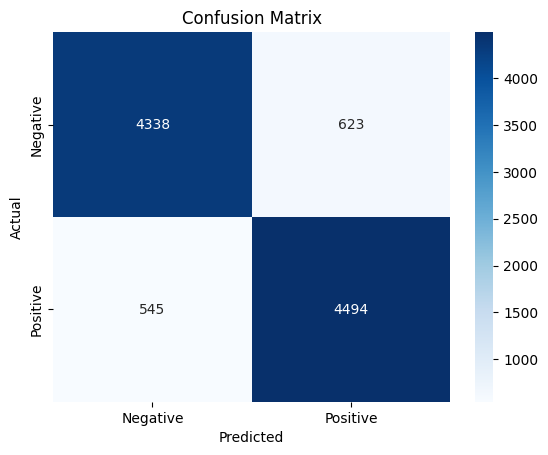

In [56]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Deep Learning (NN)-Sequential API**

# 1-Load Tensroflow

In [57]:
import tensorflow as tf
print(tf.__version__)

2.20.0


# 2. Data Loading and Exploring

In [58]:
from sklearn.model_selection import train_test_split

training_reviews, testing_reviews, training_labels, testing_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

training_reviews = training_reviews.reset_index(drop=True)
testing_reviews = testing_reviews.reset_index(drop=True)

training_labels = training_labels.reset_index(drop=True)
testing_labels = testing_labels.reset_index(drop=True)

print("The number of training reviews is {}".format(training_reviews.shape[0]))
print("The number of testing reviews  is {}".format(testing_reviews.shape[0]))

The number of training reviews is 40000
The number of testing reviews  is 10000


In [59]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(training_reviews)

In [60]:
import random
word_index = tokenizer.word_index
reverse_index = {v: k for k, v in word_index.items()}

review_number = random.randint(0, len(training_reviews) - 1)

decoded = ' '.join([
    reverse_index.get(i, '!')
    for i in training_reviews[review_number]
])

print("Label :", "POSITIVE" if training_labels.iloc[review_number] == 1 else "NEGATIVE")
print("Review:", decoded[:600])

Label : NEGATIVE
Review: ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! 


# 3-Padding

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

VOCAB_SIZE = 20000
MAXLEN = 300
EMB_DIM = 32

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

training_reviews, testing_reviews, training_labels, testing_labels = train_test_split(
    sequences,
    df['label'],
    test_size=0.2,
    random_state=42
)

x_train = pad_sequences(training_reviews, maxlen=MAXLEN, padding='post', truncating='post')
x_test  = pad_sequences(testing_reviews,  maxlen=MAXLEN, padding='post', truncating='post')

y_train = np.asarray(training_labels.map({"positive": 1, "negative": 0})).astype('float32')
y_test  = np.asarray(testing_labels.map({"positive": 1, "negative": 0})).astype('float32')

print("x_train shape:", x_train.shape)
print("x_test  shape:", x_test.shape)

x_train shape: (40000, 300)
x_test  shape: (10000, 300)


# 4-Custom Callback

In [62]:
from tensorflow.keras.callbacks import Callback

class StopTrainingCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.88:
            print("\nTarget reached → stopping training!")
            self.model.stop_training = True

# 5-Build_Sequential API

In [63]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, Dropout

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE + 1, output_dim=EMB_DIM, input_shape=(MAXLEN,)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='text_classifier_model')

model.build(input_shape=(None, MAXLEN))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "text_classifier_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       640,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       614,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,256,609 (4.79 MB)

 Trainable params: 1,256,609 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

# 6-Compile & Train

In [64]:
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks_seq = StopTrainingCallback()

best_model_saver = ModelCheckpoint(
    filepath='models/best_model.weights.h5',
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [65]:
model.compile(
    optimizer=tf.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Sequential model...")

history_seq = model.fit(
    x_train, y_train,
    epochs=2,
    validation_data=(x_test, y_test)
)

Training Sequential model...
Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.7986 - loss: 0.4158 - val_accuracy: 0.8827 - val_loss: 0.2815
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9461 - loss: 0.1537 - val_accuracy: 0.8528 - val_loss: 0.3852


# 7-Evaluate

In [66]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("Model performance on test data:")
print("Accuracy: {:.2f}%".format(test_acc * 100))

Model performance on test data:
Accuracy: 85.28%


# 8-Save & Load

In [67]:
model.save('/content/imdb_model.keras')
print("Model saved successfully")

Model saved successfully


In [68]:
from tensorflow.keras.models import load_model
model_loaded = load_model('/content/imdb_model.keras')
print("Model loaded successfully ")
model_loaded.summary()

Model loaded successfully 


Model: "text_classifier_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       640,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       614,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,769,829 (14.38 MB)

 Trainable params: 1,256,609 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,513,220 (9.59 MB)

In [69]:
#confirm same accuracy after loading
test_loss, test_acc = model_loaded.evaluate(x_test, y_test, verbose=0)
print("loaded accuracy on test data: {:.2f}%".format(test_acc * 100))

loaded accuracy on test data: 85.28%


In [70]:
#Test Model on new data
new_text = "The movie had good acting but the story was boring"

seq = tokenizer.texts_to_sequences([new_text])

padded = pad_sequences(seq, maxlen=300, padding='post', truncating='post')

prediction = model.predict(padded)

print("Positive" if prediction[0][0] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Negative


# **Comparsion between ML and dl accuracy**

In [71]:
from sklearn.metrics import accuracy_score
ml_pred = clf.predict(X_test_tfidf)
if isinstance(ml_pred[0], str):
    ml_pred = [1 if str(i).lower() == "positive" else 0 for i in ml_pred]
ml_acc = accuracy_score(y_test, ml_pred)
test_loss, dl_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"ML Accuracy: {ml_acc:.4f}")
print(f"DL Accuracy: {dl_acc:.4f}")
if ml_acc > dl_acc:
    print(" ML model performed better")
elif dl_acc > ml_acc:
    print(" DL model performed better")
else:
    print("Both models performed equally")

ML Accuracy: 0.8832
DL Accuracy: 0.8528
 ML model performed better


# **LLM(Hugging Face)**

# pipeline()

In [72]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

classifier(df['cleaned_text'].head(10).tolist())

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9790975451469421},
 {'label': 'POSITIVE', 'score': 0.9981739521026611},
 {'label': 'POSITIVE', 'score': 0.9985954165458679},
 {'label': 'NEGATIVE', 'score': 0.9996583461761475},
 {'label': 'POSITIVE', 'score': 0.9979650974273682},
 {'label': 'POSITIVE', 'score': 0.9976426959037781},
 {'label': 'POSITIVE', 'score': 0.9818481206893921},
 {'label': 'NEGATIVE', 'score': 0.9996534585952759},
 {'label': 'NEGATIVE', 'score': 0.9993891716003418},
 {'label': 'POSITIVE', 'score': 0.9997625946998596}]

# **Deployment**

In [73]:
!pip install streamlit pyngrok transformers

In [74]:
%%writefile app.py
import streamlit as st
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

st.set_page_config(page_title="NLP App", page_icon="🤖", layout="centered")

st.markdown(
    "<h1 style='text-align: center; color: #6C63FF;'>🤖 NLP Sentiment Analyzer</h1>",
    unsafe_allow_html=True
)

st.write("### Enter your text below 👇")

text = st.text_area("", height=150)

if st.button("✨ Predict"):
    result = classifier([text])[0]

    label = result['label']
    score = result['score']

    st.json({
        "label": label,
        "score": round(score, 4)
    })

Overwriting app.py


In [75]:
from pyngrok import ngrok

ngrok.set_auth_token("3DXovMwRuHKc3mwYOuQJ52fT6Uz_83qEmmYyKVP5BcGR4a2rF")

In [76]:
!pkill streamlit

In [77]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &

nohup: appending output to 'nohup.out'


In [78]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://giant-giver-unframed.ngrok-free.dev" -> "http://localhost:8501"
